# Diabetes Prediction Using Machine Learning

## Objective

This project aims to predict whether a patient is diabetic or non-diabetic using the Pima Indians Diabetes dataset.

The main goal is to compare the performance of three machine learning models:
- Logistic Regression (LR)
- Support Vector Machine (SVM)
- Random Forest (RF)

The comparison is carried out in four stages:
- Raw baseline models
- Preprocessed models
- Hyperparameter-tuned models
- Ensemble voting models

## Problem Statement

Diabetes is a major health problem, and early prediction can help in timely diagnosis and treatment.  
This project uses machine learning techniques to build and compare diabetes prediction models on the Pima Indians Diabetes dataset.

## Dataset

- Dataset Name: Pima Indians Diabetes Dataset
- Source: UCI Machine Learning Repository / Kaggle
- Total Records: 768
- Features: 8 input features + 1 target column
- Target Variable: Outcome (0 = Non-Diabetic, 1 = Diabetic)

## Workflow Overview

The notebook is organized into the following sections:

1. **Data loading and inspection**  
   - Load the Pima Indians Diabetes dataset  
   - Explore structure, summary statistics, and count of invalid zeros

2. **Raw baselines (minimal preprocessing)**  
   - Train Logistic Regression, SVM, and Random Forest on the original dataset  
   - Record initial Accuracy, Precision, Recall, F1-score, and ROC-AUC

3. **Preprocessed pipelines (zero→NaN + imputer + scaler)**  
   - Replace medically invalid zeros with NaN  
   - Apply median imputation and scaling (for LR and SVM)  
   - Retrain LR, SVM, and RF on the cleaned data

4. **Hyperparameter tuning (cv = 5)**  
   - Use GridSearchCV and RandomizedSearchCV for LR, SVM, and RF  
   - Compare best parameters and 5-fold F1-scores

5. **Cross-validation stability (5-fold vs 10-fold)**  
   - Evaluate best LR, SVM, and RF models with 5-fold and 10-fold CV  
   - Compare mean F1 and standard deviation

6. **Ensemble voting models**  
   - Build hard and soft voting ensembles (LR + SVM + RF, LR + RF)  
   - Compare ensemble performance to the best single Random Forest model

7. **Final comparison tables and insights**  
   - Summarize all models (raw, preprocessed, tuned, ensembles)  
   - Present tables, charts, and final observations

.

# 1. Data loading and inspection

In [ ]:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nicer
sns.set(style="whitegrid")

# Scikit-learn utilities
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

print("Imports done.")

In [ ]:
# Load the Pima Indians Diabetes dataset
df = pd.read_csv("diabetes.csv")

# Show first 5 rows
df.head()

Table 1

In [ ]:
# Basic structure
print("Shape:", df.shape)       # rows, columns
print("\nInfo:")
print(df.info())

# Statistical summary
print("\nDescribe:")
print(df.describe())

In [ ]:
# Check target distribution
print(df["Outcome"].value_counts())
print("\nProportion:")
print(df["Outcome"].value_counts(normalize=True))

In [ ]:
# Columns where zero is medically invalid
invalid_zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in invalid_zero_cols:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count} zeros")

# 2. Raw baselines (minimal preprocessing)

## 2.1 Raw Logistic Regression (original df)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Use the original dataframe df (with zeros intact) for raw baseline
X_raw = df.drop("Outcome", axis=1)
y_raw = df["Outcome"]

# Train-test split for raw data
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw,
    y_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_raw
)

# Define a raw baseline pipeline: scale + logistic regression
log_reg_raw_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

# Fit on raw training data
log_reg_raw_pipe.fit(X_train_raw, y_train_raw)

# Predict on raw test data
y_pred_raw_lr = log_reg_raw_pipe.predict(X_test_raw)
y_proba_raw_lr = log_reg_raw_pipe.predict_proba(X_test_raw)[:, 1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt

# Evaluate raw Logistic Regression baseline
acc_lr_raw = accuracy_score(y_test_raw, y_pred_raw_lr)
prec_lr_raw = precision_score(y_test_raw, y_pred_raw_lr)
recall_lr_raw = recall_score(y_test_raw, y_pred_raw_lr)
f1_lr_raw = f1_score(y_test_raw, y_pred_raw_lr)
auc_lr_raw = roc_auc_score(y_test_raw, y_proba_raw_lr)

print("Raw Logistic Regression performance:")
print(f"Accuracy : {acc_lr_raw:.4f}")
print(f"Precision: {prec_lr_raw:.4f}")
print(f"Recall   : {recall_lr_raw:.4f}")
print(f"F1-score : {f1_lr_raw:.4f}")
print(f"ROC-AUC  : {auc_lr_raw:.4f}")

# Confusion matrix
cm_lr_raw = confusion_matrix(y_test_raw, y_pred_raw_lr)
print("\nConfusion Matrix (Raw LR):")
print(cm_lr_raw)

print("\nClassification Report (Raw LR):")
print(classification_report(y_test_raw, y_pred_raw_lr))

# ROC curve
fpr_lr_raw, tpr_lr_raw, thresholds_lr_raw = roc_curve(y_test_raw, y_proba_raw_lr)

plt.figure(figsize=(6, 4))
plt.plot(fpr_lr_raw, tpr_lr_raw, label=f"Raw LR (AUC = {auc_lr_raw:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Raw Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

Fig 1 :ROC Curve - Raw Logistic Regression

## 2.2 Raw SVM (original df)


In [ ]:
from sklearn.svm import SVC

# Raw SVM pipeline: scale + SVM classifier
svm_raw_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True))  # probability=True so we can get ROC-AUC
])

# Fit on raw training data
svm_raw_pipe.fit(X_train_raw, y_train_raw)

# Predict on raw test data
y_pred_raw_svm = svm_raw_pipe.predict(X_test_raw)
y_proba_raw_svm = svm_raw_pipe.predict_proba(X_test_raw)[:, 1]

# Evaluate raw SVM baseline
acc_svm_raw = accuracy_score(y_test_raw, y_pred_raw_svm)
prec_svm_raw = precision_score(y_test_raw, y_pred_raw_svm)
recall_svm_raw = recall_score(y_test_raw, y_pred_raw_svm)
f1_svm_raw = f1_score(y_test_raw, y_pred_raw_svm)
auc_svm_raw = roc_auc_score(y_test_raw, y_proba_raw_svm)

print("Raw SVM performance:")
print(f"Accuracy : {acc_svm_raw:.4f}")
print(f"Precision: {prec_svm_raw:.4f}")
print(f"Recall   : {recall_svm_raw:.4f}")
print(f"F1-score : {f1_svm_raw:.4f}")
print(f"ROC-AUC  : {auc_svm_raw:.4f}")

# Confusion matrix
cm_svm_raw = confusion_matrix(y_test_raw, y_pred_raw_svm)
print("\nConfusion Matrix (Raw SVM):")
print(cm_svm_raw)

print("\nClassification Report (Raw SVM):")
print(classification_report(y_test_raw, y_pred_raw_svm))

# ROC curve
fpr_svm_raw, tpr_svm_raw, thresholds_svm_raw = roc_curve(y_test_raw, y_proba_raw_svm)

plt.figure(figsize=(6, 4))
plt.plot(fpr_svm_raw, tpr_svm_raw, label=f"Raw SVM (AUC = {auc_svm_raw:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Raw SVM")
plt.legend()
plt.grid(True)
plt.show()

Fig 2:ROC Curve - Raw SVM

## 2.3 Raw Random Forest (original df)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Raw Random Forest pipeline: just the model (no scaler needed, but using Pipeline for consistency)
rf_raw_pipe = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# Fit on raw training data
rf_raw_pipe.fit(X_train_raw, y_train_raw)

# Predict on raw test data
y_pred_raw_rf = rf_raw_pipe.predict(X_test_raw)
y_proba_raw_rf = rf_raw_pipe.predict_proba(X_test_raw)[:, 1]

# Evaluate raw Random Forest baseline
acc_rf_raw = accuracy_score(y_test_raw, y_pred_raw_rf)
prec_rf_raw = precision_score(y_test_raw, y_pred_raw_rf)
recall_rf_raw = recall_score(y_test_raw, y_pred_raw_rf)
f1_rf_raw = f1_score(y_test_raw, y_pred_raw_rf)
auc_rf_raw = roc_auc_score(y_test_raw, y_proba_raw_rf)

print("Raw Random Forest performance:")
print(f"Accuracy : {acc_rf_raw:.4f}")
print(f"Precision: {prec_rf_raw:.4f}")
print(f"Recall   : {recall_rf_raw:.4f}")
print(f"F1-score : {f1_rf_raw:.4f}")
print(f"ROC-AUC  : {auc_rf_raw:.4f}")

# Confusion matrix
cm_rf_raw = confusion_matrix(y_test_raw, y_pred_raw_rf)
print("\nConfusion Matrix (Raw RF):")
print(cm_rf_raw)

print("\nClassification Report (Raw RF):")
print(classification_report(y_test_raw, y_pred_raw_rf))

# ROC curve
fpr_rf_raw, tpr_rf_raw, thresholds_rf_raw = roc_curve(y_test_raw, y_proba_raw_rf)

plt.figure(figsize=(6, 4))
plt.plot(fpr_rf_raw, tpr_rf_raw, label=f"Raw RF (AUC = {auc_rf_raw:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Raw Random Forest")
plt.legend()
plt.grid(True)
plt.show()

Fig 3: ROC Curve - Raw Random Forest

In [ ]:
#comparison of roc curves for  lr,svm,rf
from sklearn.metrics import roc_curve, roc_auc_score
plt.figure(figsize=(6, 4))
plt.plot(fpr_lr_raw,  tpr_lr_raw,  label=f"LR (AUC = {auc_lr_raw:.3f})")
plt.plot(fpr_svm_raw, tpr_svm_raw, label=f"SVM (AUC = {auc_svm_raw:.3f})")
plt.plot(fpr_rf_raw,  tpr_rf_raw,  label=f"RF (AUC = {auc_rf_raw:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – Raw Baseline Models")
plt.legend()
plt.grid(True)
plt.show()

**Fig. 4.** ROC curves of the raw Logistic Regression, SVM, and Random Forest baselines on the original dataset.

In [ ]:
raw_rows = []

def add_raw_row(name, auc, acc, recall, precision, f1):
    raw_rows.append({
        "Classifier": name,
        "AUC": auc,
        "Accuracy": acc,
        "Sensitivity (Recall)": recall,
        "Precision": precision,
        "F1-score": f1
    })

add_raw_row("Logistic Regression (raw)",
            auc_lr_raw, acc_lr_raw, recall_lr_raw, prec_lr_raw, f1_lr_raw)

add_raw_row("SVM (raw)",
            auc_svm_raw, acc_svm_raw, recall_svm_raw, prec_svm_raw, f1_svm_raw)

add_raw_row("Random Forest (raw)",
            auc_rf_raw, acc_rf_raw, recall_rf_raw, prec_rf_raw, f1_rf_raw)

raw_summary_df = pd.DataFrame(raw_rows)
raw_summary_df

**Table 2.** Performance metrics of the raw baseline models (Logistic Regression, SVM, and Random Forest) on the original dataset.

# 3. Preprocessed pipelines (zero→NaN + imputer + scaler)

### 3.1 Create cleaned dataframe (df_clean)


In [ ]:
import numpy as np  # ensure numpy is available as np

# Make a cleaned copy of the original dataframe
df_clean = df.copy()

# Replace invalid zeros with NaN in all specified columns at once
df_clean[invalid_zero_cols] = df_clean[invalid_zero_cols].replace(0, np.nan)

# Check how many NaNs we introduced in each column
print("Number of NaNs after replacing zeros:")
print(df_clean[invalid_zero_cols].isna().sum())

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Features and target from cleaned dataframe (zeros -> NaN)
X_clean = df_clean.drop("Outcome", axis=1)
y_clean = df_clean["Outcome"]

# Train-test split on cleaned data
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)

### 3.2 Logistic Regression pipeline on cleaned data


In [ ]:
# Pipeline: median imputer -> scaler -> Logistic Regression
log_reg_clean_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

# Fit on cleaned training data (with NaNs; pipeline will handle them)
log_reg_clean_pipe.fit(X_train_clean, y_train_clean)

# Predict on cleaned test data
y_pred_clean_lr = log_reg_clean_pipe.predict(X_test_clean)
y_proba_clean_lr = log_reg_clean_pipe.predict_proba(X_test_clean)[:, 1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt

# Evaluate preprocessed Logistic Regression
acc_lr_clean = accuracy_score(y_test_clean, y_pred_clean_lr)
prec_lr_clean = precision_score(y_test_clean, y_pred_clean_lr)
recall_lr_clean = recall_score(y_test_clean, y_pred_clean_lr)
f1_lr_clean = f1_score(y_test_clean, y_pred_clean_lr)
auc_lr_clean = roc_auc_score(y_test_clean, y_proba_clean_lr)

print("Preprocessed Logistic Regression performance:")
print(f"Accuracy : {acc_lr_clean:.4f}")
print(f"Precision: {prec_lr_clean:.4f}")
print(f"Recall   : {recall_lr_clean:.4f}")
print(f"F1-score : {f1_lr_clean:.4f}")
print(f"ROC-AUC  : {auc_lr_clean:.4f}")

# Confusion matrix
cm_lr_clean = confusion_matrix(y_test_clean, y_pred_clean_lr)
print("\nConfusion Matrix (Preprocessed LR):")
print(cm_lr_clean)

print("\nClassification Report (Preprocessed LR):")
print(classification_report(y_test_clean, y_pred_clean_lr))

# ROC curve
fpr_lr_clean, tpr_lr_clean, thresholds_lr_clean = roc_curve(y_test_clean, y_proba_clean_lr)

plt.figure(figsize=(6, 4))
plt.plot(fpr_lr_clean, tpr_lr_clean, label=f"Preprocessed LR (AUC = {auc_lr_clean:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Preprocessed Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

fig 5:ROC Curve - Preprocessed Logistic Regression


### 3.3 Preprocessed SVM pipeline


In [ ]:
from sklearn.svm import SVC

# Pipeline: median imputer -> scaler -> SVM
svm_clean_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True))  # probability=True for ROC-AUC
])

# Fit on cleaned training data
svm_clean_pipe.fit(X_train_clean, y_train_clean)

# Predict on cleaned test data
y_pred_clean_svm = svm_clean_pipe.predict(X_test_clean)
y_proba_clean_svm = svm_clean_pipe.predict_proba(X_test_clean)[:, 1]

# Evaluate preprocessed SVM
acc_svm_clean = accuracy_score(y_test_clean, y_pred_clean_svm)
prec_svm_clean = precision_score(y_test_clean, y_pred_clean_svm)
recall_svm_clean = recall_score(y_test_clean, y_pred_clean_svm)
f1_svm_clean = f1_score(y_test_clean, y_pred_clean_svm)
auc_svm_clean = roc_auc_score(y_test_clean, y_proba_clean_svm)

print("Preprocessed SVM performance:")
print(f"Accuracy : {acc_svm_clean:.4f}")
print(f"Precision: {prec_svm_clean:.4f}")
print(f"Recall   : {recall_svm_clean:.4f}")
print(f"F1-score : {f1_svm_clean:.4f}")
print(f"ROC-AUC  : {auc_svm_clean:.4f}")

# Confusion matrix
cm_svm_clean = confusion_matrix(y_test_clean, y_pred_clean_svm)
print("\nConfusion Matrix (Preprocessed SVM):")
print(cm_svm_clean)

print("\nClassification Report (Preprocessed SVM):")
print(classification_report(y_test_clean, y_pred_clean_svm))

# ROC curve
fpr_svm_clean, tpr_svm_clean, thresholds_svm_clean = roc_curve(y_test_clean, y_proba_clean_svm)

plt.figure(figsize=(6, 4))
plt.plot(fpr_svm_clean, tpr_svm_clean, label=f"Preprocessed SVM (AUC = {auc_svm_clean:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Preprocessed SVM")
plt.legend()
plt.grid(True)
plt.show()

Fig 6 :ROC Curve - Preprocessed SVM

### 3.4 Preprocessed Random Forest pipeline

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Pipeline: median imputer -> Random Forest (no scaler needed)
rf_clean_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# Fit on cleaned training data
rf_clean_pipe.fit(X_train_clean, y_train_clean)

# Predict on cleaned test data
y_pred_clean_rf = rf_clean_pipe.predict(X_test_clean)
y_proba_clean_rf = rf_clean_pipe.predict_proba(X_test_clean)[:, 1]

# Evaluate preprocessed Random Forest
acc_rf_clean = accuracy_score(y_test_clean, y_pred_clean_rf)
prec_rf_clean = precision_score(y_test_clean, y_pred_clean_rf)
recall_rf_clean = recall_score(y_test_clean, y_pred_clean_rf)
f1_rf_clean = f1_score(y_test_clean, y_pred_clean_rf)
auc_rf_clean = roc_auc_score(y_test_clean, y_proba_clean_rf)

print("Preprocessed Random Forest performance:")
print(f"Accuracy : {acc_rf_clean:.4f}")
print(f"Precision: {prec_rf_clean:.4f}")
print(f"Recall   : {recall_rf_clean:.4f}")
print(f"F1-score : {f1_rf_clean:.4f}")
print(f"ROC-AUC  : {auc_rf_clean:.4f}")

# Confusion matrix
cm_rf_clean = confusion_matrix(y_test_clean, y_pred_clean_rf)
print("\nConfusion Matrix (Preprocessed RF):")
print(cm_rf_clean)

print("\nClassification Report (Preprocessed RF):")
print(classification_report(y_test_clean, y_pred_clean_rf))

# ROC curve
fpr_rf_clean, tpr_rf_clean, thresholds_rf_clean = roc_curve(y_test_clean, y_proba_clean_rf)

plt.figure(figsize=(6, 4))
plt.plot(fpr_rf_clean, tpr_rf_clean, label=f"Preprocessed RF (AUC = {auc_rf_clean:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Preprocessed Random Forest")
plt.legend()
plt.grid(True)
plt.show()

Fig 7 : ROC Curve - Preprocessed Random Forest

In [ ]:
plt.figure(figsize=(6, 4))

# Preprocessed LR, SVM, RF (pipelines on df_clean)
fpr_lr,  tpr_lr,  _ = roc_curve(y_test_clean, y_proba_clean_lr)
fpr_svm, tpr_svm, _ = roc_curve(y_test_clean, y_proba_clean_svm)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test_clean, y_proba_clean_rf)

auc_lr  = roc_auc_score(y_test_clean, y_proba_clean_lr)
auc_svm = roc_auc_score(y_test_clean, y_proba_clean_svm)
auc_rf  = roc_auc_score(y_test_clean, y_proba_clean_rf)

plt.plot(fpr_lr,  tpr_lr,  label=f"LR (AUC = {auc_lr:.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.3f})")
plt.plot(fpr_rf,  tpr_rf,  label=f"RF (AUC = {auc_rf:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – Preprocessed Models")
plt.legend()
plt.grid(True)
plt.show()

###**Fig.8** ROC curves for preprocessed models

In [ ]:
pre_rows = []

def add_pre_row(name, auc, acc, recall, precision, f1):
    pre_rows.append({
        "Classifier": name,
        "AUC": auc,
        "Accuracy": acc,
        "Sensitivity (Recall)": recall,
        "Precision": precision,
        "F1-score": f1
    })

add_pre_row("Logistic Regression (preprocessed)",
            auc_lr_clean, acc_lr_clean, recall_lr_clean, prec_lr_clean, f1_lr_clean)

add_pre_row("SVM (preprocessed)",
            auc_svm_clean, acc_svm_clean, recall_svm_clean, prec_svm_clean, f1_svm_clean)

add_pre_row("Random Forest (preprocessed)",
            auc_rf_clean, acc_rf_clean, recall_rf_clean, prec_rf_clean, f1_rf_clean)

pre_summary_df = pd.DataFrame(pre_rows)
pre_summary_df

**Table 3.** Performance metrics of the preprocessed Logistic Regression, SVM, and Random Forest models

# 4. Hyperparameter tuning (cv = 5)

## 4.1 Logistic Regression tuning
- GridSearchCV (cv = 5)
- RandomizedSearchCV (cv = 5)



In [ ]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid for Logistic Regression
param_grid_lr = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"]
}

# GridSearchCV with 5-fold cross-validation
grid_search_lr = GridSearchCV(
    estimator=log_reg_clean_pipe,
    param_grid=param_grid_lr,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit grid search on the cleaned training data
grid_search_lr.fit(X_train_clean, y_train_clean)

print("Best parameters (GridSearchCV, LR):", grid_search_lr.best_params_)
print("Best mean F1-score (cv=5):", grid_search_lr.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters (GridSearchCV, LR): {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best mean F1-score (cv=5): 0.65398264737667


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Parameter distributions for RandomizedSearchCV (wider range for C)
param_distributions_lr = {
    "model__C": np.logspace(-3, 3, 20),  # 0.001 to 1000 (log-spaced)
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

# RandomizedSearchCV with 5-fold cross-validation
random_search_lr = RandomizedSearchCV(
    estimator=log_reg_clean_pipe,
    param_distributions=param_distributions_lr,
    n_iter=20,        # try 20 random combinations
    scoring="f1",
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit randomized search on the cleaned training data
random_search_lr.fit(X_train_clean, y_train_clean)

print("Best parameters (RandomizedSearchCV, LR):", random_search_lr.best_params_)
print("Best mean F1-score (cv=5):", random_search_lr.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters (RandomizedSearchCV, LR): {'model__solver': 'lbfgs', 'model__penalty': 'l2', 'model__C': np.float64(0.6951927961775606)}
Best mean F1-score (cv=5): 0.6496858824779203


## 4.2 SVM tuning
- GridSearchCV (cv = 5)
- RandomizedSearchCV (cv = 5)



In [ ]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid for SVM
param_grid_svm = {
    "model__C": [0.1, 1, 10, 100],
    "model__kernel": ["rbf"],          # start with RBF kernel
    "model__gamma": ["scale", 0.01, 0.1, 1.0]
}

# GridSearchCV with 5-fold cross-validation for SVM
grid_search_svm = GridSearchCV(
    estimator=svm_clean_pipe,
    param_grid=param_grid_svm,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit grid search on the cleaned training data
grid_search_svm.fit(X_train_clean, y_train_clean)

print("Best parameters (GridSearchCV, SVM):", grid_search_svm.best_params_)
print("Best mean F1-score (cv=5):", grid_search_svm.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters (GridSearchCV, SVM): {'model__C': 10, 'model__gamma': 0.01, 'model__kernel': 'rbf'}
Best mean F1-score (cv=5): 0.6288067206149398


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Parameter distributions for RandomizedSearchCV (wider ranges)
param_distributions_svm = {
    "model__C": np.logspace(-2, 3, 20),     # 0.01 to 1000
    "model__kernel": ["rbf"],
    "model__gamma": np.logspace(-3, 1, 20)  # 0.001 to 10
}

# RandomizedSearchCV with 5-fold cross-validation for SVM
random_search_svm = RandomizedSearchCV(
    estimator=svm_clean_pipe,
    param_distributions=param_distributions_svm,
    n_iter=20,         # try 20 random combinations
    scoring="f1",
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit randomized search on the cleaned training data
random_search_svm.fit(X_train_clean, y_train_clean)

print("Best parameters (RandomizedSearchCV, SVM):", random_search_svm.best_params_)
print("Best mean F1-score (cv=5):", random_search_svm.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters (RandomizedSearchCV, SVM): {'model__kernel': 'rbf', 'model__gamma': np.float64(0.001), 'model__C': np.float64(48.32930238571752)}
Best mean F1-score (cv=5): 0.6302115020910043


## 4.3 Random Forest tuning
- GridSearchCV (cv = 5)
- RandomizedSearchCV (cv = 5)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Hyperparameter grid for Random Forest
param_grid_rf = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

# GridSearchCV with 5-fold cross-validation for RF
grid_search_rf = GridSearchCV(
    estimator=rf_clean_pipe,
    param_grid=param_grid_rf,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit grid search on the cleaned training data
grid_search_rf.fit(X_train_clean, y_train_clean)

print("Best parameters (GridSearchCV, RF):", grid_search_rf.best_params_)
print("Best mean F1-score (cv=5):", grid_search_rf.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters (GridSearchCV, RF): {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best mean F1-score (cv=5): 0.6538602255388483


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Parameter distributions for RandomizedSearchCV (wider RF search)
param_distributions_rf = {
    "model__n_estimators": np.arange(100, 501, 50),   # 100 to 500
    "model__max_depth": [None, 5, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10, 15],
    "model__min_samples_leaf": [1, 2, 4, 6],
    "model__max_features": ["sqrt", "log2", None]
}

# RandomizedSearchCV with 5-fold cross-validation for RF
random_search_rf = RandomizedSearchCV(
    estimator=rf_clean_pipe,
    param_distributions=param_distributions_rf,
    n_iter=25,       # try 25 random combinations
    scoring="f1",
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit randomized search on the cleaned training data
random_search_rf.fit(X_train_clean, y_train_clean)

print("Best parameters (RandomizedSearchCV, RF):", random_search_rf.best_params_)
print("Best mean F1-score (cv=5):", random_search_rf.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best parameters (RandomizedSearchCV, RF): {'model__n_estimators': np.int64(450), 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_features': None, 'model__max_depth': 20}
Best mean F1-score (cv=5): 0.6517852710704535


In [ ]:
#summary

tuning_rows = []

def add_tuning_row(model_name, method, best_score, best_params):
    tuning_rows.append({
        "Model": model_name,
        "Search Method": method,
        "Best F1 (cv=5)": best_score,
        "Best Params": best_params
    })

# Logistic Regression – GridSearchCV
add_tuning_row(
    "Logistic Regression",
    "GridSearchCV",
    grid_search_lr.best_score_,
    grid_search_lr.best_params_
)
add_tuning_row(
    "Logistic Regression",
    "RandomizedSearchCV",
    random_search_lr.best_score_,
    random_search_lr.best_params_
)

# SVM – GridSearchCV (only if you ran it)
add_tuning_row(
    "SVM",
    "GridSearchCV",
    grid_search_svm.best_score_,
    grid_search_svm.best_params_
)

# SVM – RandomizedSearchCV (only if you ran it)
add_tuning_row(
    "SVM",
    "RandomizedSearchCV",
    random_search_svm.best_score_,
    random_search_svm.best_params_
)

# Random Forest – GridSearchCV (only if you ran it)
add_tuning_row(
    "Random Forest",
    "GridSearchCV",
    grid_search_rf.best_score_,
    grid_search_rf.best_params_
)

# Random Forest – RandomizedSearchCV
add_tuning_row(
    "Random Forest",
    "RandomizedSearchCV",
    random_search_rf.best_score_,
    random_search_rf.best_params_
)

tuning_df = pd.DataFrame(tuning_rows)
tuning_df

,Model,Search Method,Best F1 (cv=5),Best Params
0,Logistic Regression,GridSearchCV,0.653983,"{'model__C': 0.1, 'model__penalty': 'l2', 'mod..."
1,Logistic Regression,RandomizedSearchCV,0.649686,"{'model__solver': 'lbfgs', 'model__penalty': '..."
2,SVM,GridSearchCV,0.628807,"{'model__C': 10, 'model__gamma': 0.01, 'model_..."
3,SVM,RandomizedSearchCV,0.630212,"{'model__kernel': 'rbf', 'model__gamma': 0.001..."
4,Random Forest,GridSearchCV,0.653860,"{'model__max_depth': None, 'model__min_samples..."
5,Random Forest,RandomizedSearchCV,0.651785,"{'model__n_estimators': 450, 'model__min_sampl..."


**Table 4.** Best hyperparameters and 5-fold cross-validation F1-scores obtained by GridSearchCV and RandomizedSearchCV for LR, SVM, and RF.

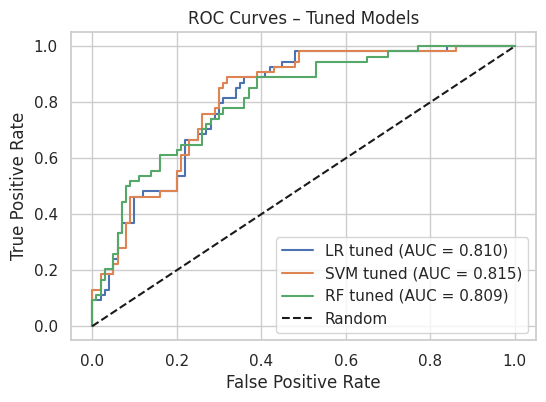

In [ ]:
# ROC curves of the tuned Logistic Regression, SVM, and Random Forest models on the test set.
best_lr_model = grid_search_lr.best_estimator_
best_svm_model = random_search_svm.best_estimator_
best_rf_model = grid_search_rf.best_estimator_

from sklearn.metrics import roc_curve, roc_auc_score

# Predict probabilities with tuned models
y_proba_lr_tuned  = best_lr_model.predict_proba(X_test_clean)[:, 1]
y_proba_svm_tuned = best_svm_model.predict_proba(X_test_clean)[:, 1]
y_proba_rf_tuned  = best_rf_model.predict_proba(X_test_clean)[:, 1]

# ROC curves
fpr_lr_tuned,  tpr_lr_tuned,  _ = roc_curve(y_test_clean, y_proba_lr_tuned)
fpr_svm_tuned, tpr_svm_tuned, _ = roc_curve(y_test_clean, y_proba_svm_tuned)
fpr_rf_tuned,  tpr_rf_tuned,  _ = roc_curve(y_test_clean, y_proba_rf_tuned)

# AUCs
auc_lr_tuned  = roc_auc_score(y_test_clean, y_proba_lr_tuned)
auc_svm_tuned = roc_auc_score(y_test_clean, y_proba_svm_tuned)
auc_rf_tuned  = roc_auc_score(y_test_clean, y_proba_rf_tuned)

plt.figure(figsize=(6, 4))
plt.plot(fpr_lr_tuned,  tpr_lr_tuned,  label=f"LR tuned (AUC = {auc_lr_tuned:.3f})")
plt.plot(fpr_svm_tuned, tpr_svm_tuned, label=f"SVM tuned (AUC = {auc_svm_tuned:.3f})")
plt.plot(fpr_rf_tuned,  tpr_rf_tuned,  label=f"RF tuned (AUC = {auc_rf_tuned:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – Tuned Models")
plt.legend()
plt.grid(True)
plt.show()

**Fig. 9.** ROC curves of the tuned Logistic Regression, SVM, and Random Forest models on the test set.

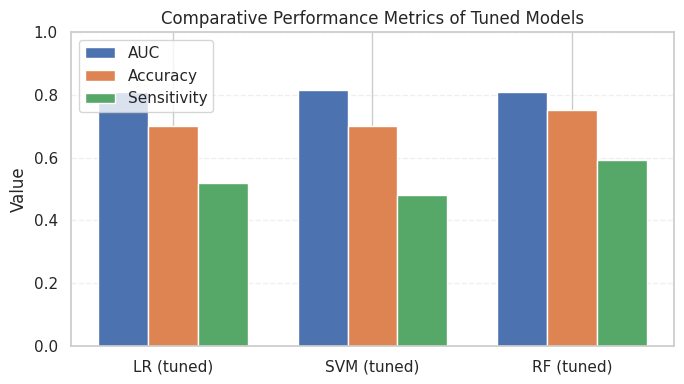

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

models = ["LR (tuned)", "SVM (tuned)", "RF (tuned)"]

auc_values    = [auc_lr_tuned_test,  auc_svm_tuned_test,  auc_rf_tuned_test]
acc_values    = [acc_lr_tuned_test,  acc_svm_tuned_test,  acc_rf_tuned_test]
recall_values = [recall_lr_tuned_test, recall_svm_tuned_test, recall_rf_tuned_test]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(7, 4))
plt.bar(x - width, auc_values,    width, label="AUC")
plt.bar(x,         acc_values,    width, label="Accuracy")
plt.bar(x + width, recall_values, width, label="Sensitivity")

plt.xticks(x, models)
plt.ylabel("Value")
plt.title("Comparative Performance Metrics of Tuned Models")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

Fig 10 bar chart

# 5. Cross-validation stability (5-fold vs 10-fold)

## 5.1 Logistic Regression (best tuned model)


In [ ]:
from sklearn.model_selection import cross_val_score

# Choose the best model from GridSearchCV (or RandomizedSearchCV if you prefer)
best_lr_model = grid_search_lr.best_estimator_

# 5-fold CV on the best LR pipeline
scores_lr_cv5 = cross_val_score(
    best_lr_model,
    X_train_clean,
    y_train_clean,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# 10-fold CV on the best LR pipeline
scores_lr_cv10 = cross_val_score(
    best_lr_model,
    X_train_clean,
    y_train_clean,
    cv=10,
    scoring="f1",
    n_jobs=-1
)

print("Best LR model F1 (5-fold CV):  mean =", scores_lr_cv5.mean(), ", std =", scores_lr_cv5.std())
print("Best LR model F1 (10-fold CV): mean =", scores_lr_cv10.mean(), ", std =", scores_lr_cv10.std())

Best LR model F1 (5-fold CV):  mean = 0.65398264737667 , std = 0.023241812027156392
Best LR model F1 (10-fold CV): mean = 0.6506417551834789 , std = 0.049315837942299955


## 5.2 SVM (best tuned model)


In [ ]:
from sklearn.model_selection import cross_val_score

# Choose the best SVM model
best_svm_model = random_search_svm.best_estimator_

# 5-fold CV on best SVM pipeline
scores_svm_cv5 = cross_val_score(
    best_svm_model,
    X_train_clean,
    y_train_clean,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# 10-fold CV on best SVM pipeline
scores_svm_cv10 = cross_val_score(
    best_svm_model,
    X_train_clean,
    y_train_clean,
    cv=10,
    scoring="f1",
    n_jobs=-1
)

print("Best SVM model F1 (5-fold CV):  mean =", scores_svm_cv5.mean(), ", std =", scores_svm_cv5.std())
print("Best SVM model F1 (10-fold CV): mean =", scores_svm_cv10.mean(), ", std =", scores_svm_cv10.std())

Best SVM model F1 (5-fold CV):  mean = 0.6302115020910043 , std = 0.03447132528975901
Best SVM model F1 (10-fold CV): mean = 0.6347990570333233 , std = 0.06038503522202996



## 5.3 Random Forest (best tuned model)

In [ ]:
from sklearn.model_selection import cross_val_score

# Choose best RF pipeline
best_rf_model = grid_search_rf.best_estimator_


# 5-fold CV on best RF pipeline
scores_rf_cv5 = cross_val_score(
    best_rf_model,
    X_train_clean,
    y_train_clean,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# 10-fold CV on best RF pipeline
scores_rf_cv10 = cross_val_score(
    best_rf_model,
    X_train_clean,
    y_train_clean,
    cv=10,
    scoring="f1",
    n_jobs=-1
)

print("Best RF model F1 (5-fold CV):  mean =", scores_rf_cv5.mean(),  ", std =", scores_rf_cv5.std())
print("Best RF model F1 (10-fold CV): mean =", scores_rf_cv10.mean(), ", std =", scores_rf_cv10.std())

Best RF model F1 (5-fold CV):  mean = 0.6538602255388483 , std = 0.03977249695275659
Best RF model F1 (10-fold CV): mean = 0.6158541067655114 , std = 0.08871895270916176


In [ ]:
cv_rows = []

# Logistic Regression
cv_rows.append({
    "Model": "Logistic Regression (tuned)",
    "CV folds (k)": 5,
    "Mean F1": scores_lr_cv5.mean(),
    "Std F1": scores_lr_cv5.std()
})
cv_rows.append({
    "Model": "Logistic Regression (tuned)",
    "CV folds (k)": 10,
    "Mean F1": scores_lr_cv10.mean(),
    "Std F1": scores_lr_cv10.std()
})

# SVM
cv_rows.append({
    "Model": "SVM (tuned)",
    "CV folds (k)": 5,
    "Mean F1": scores_svm_cv5.mean(),
    "Std F1": scores_svm_cv5.std()
})
cv_rows.append({
    "Model": "SVM (tuned)",
    "CV folds (k)": 10,
    "Mean F1": scores_svm_cv10.mean(),
    "Std F1": scores_svm_cv10.std()
})

# Random Forest
cv_rows.append({
    "Model": "Random Forest (tuned)",
    "CV folds (k)": 5,
    "Mean F1": scores_rf_cv5.mean(),
    "Std F1": scores_rf_cv5.std()
})
cv_rows.append({
    "Model": "Random Forest (tuned)",
    "CV folds (k)": 10,
    "Mean F1": scores_rf_cv10.mean(),
    "Std F1": scores_rf_cv10.std()
})

cv_summary_df = pd.DataFrame(cv_rows)
cv_summary_df

,Model,CV folds (k),Mean F1,Std F1
0,Logistic Regression (tuned),5,0.653983,0.023242
1,Logistic Regression (tuned),10,0.650642,0.049316
2,SVM (tuned),5,0.630212,0.034471
3,SVM (tuned),10,0.634799,0.060385
4,Random Forest (tuned),5,0.653860,0.039772
5,Random Forest (tuned),10,0.615854,0.088719


**Table 5.** Mean and standard deviation of F1-scores for the tuned Logistic Regression, SVM, and Random Forest models using 5-fold and 10-fold cross-validation.

# 6. Ensemble voting models

## 6.1 LR + SVM + RF (hard and soft voting)


In [ ]:
from sklearn.ensemble import VotingClassifier

# Best tuned pipelines from previous phases
best_lr_model = grid_search_lr.best_estimator_        # tuned LR pipeline
best_svm_model = random_search_svm.best_estimator_    # tuned SVM pipeline
best_rf_model = grid_search_rf.best_estimator_        # tuned RF pipeline

In [ ]:
# Hard voting ensemble: majority vote among tuned LR, SVM, RF
voting_hard = VotingClassifier(
    estimators=[
        ("lr", best_lr_model),
        ("svm", best_svm_model),
        ("rf", best_rf_model)
    ],
    voting="hard"
)

# Fit the ensemble on the cleaned training data
voting_hard.fit(X_train_clean, y_train_clean)

# Predict on cleaned test data
y_pred_voting_hard = voting_hard.predict(X_test_clean)

# Evaluate hard voting ensemble
acc_vh = accuracy_score(y_test_clean, y_pred_voting_hard)
prec_vh = precision_score(y_test_clean, y_pred_voting_hard)
recall_vh = recall_score(y_test_clean, y_pred_voting_hard)
f1_vh = f1_score(y_test_clean, y_pred_voting_hard)

print("Hard Voting Ensemble performance:")
print(f"Accuracy : {acc_vh:.4f}")
print(f"Precision: {prec_vh:.4f}")
print(f"Recall   : {recall_vh:.4f}")
print(f"F1-score : {f1_vh:.4f}")

Hard Voting Ensemble performance:
Accuracy : 0.7013
Precision: 0.5870
Recall   : 0.5000
F1-score : 0.5400


Soft Voting Ensemble performance:
Accuracy : 0.6948
Precision: 0.5778
Recall   : 0.4815
F1-score : 0.5253
ROC-AUC  : 0.8150


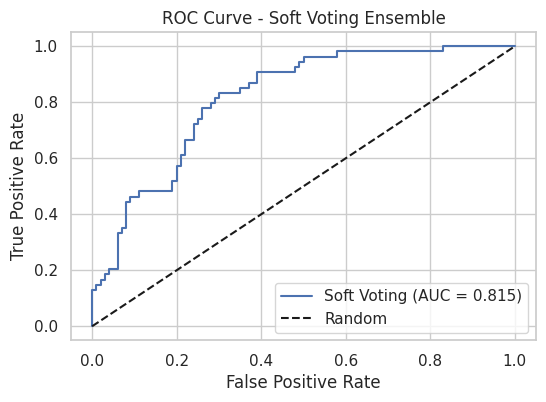

In [ ]:
# Soft voting ensemble: average predicted probabilities from tuned LR, SVM, RF
voting_soft = VotingClassifier(
    estimators=[
        ("lr", best_lr_model),
        ("svm", best_svm_model),
        ("rf", best_rf_model)
    ],
    voting="soft"
)

# Fit the soft voting ensemble
voting_soft.fit(X_train_clean, y_train_clean)

# Predict class labels and probabilities on test data
y_pred_voting_soft = voting_soft.predict(X_test_clean)
y_proba_voting_soft = voting_soft.predict_proba(X_test_clean)[:, 1]

# Evaluate soft voting ensemble
acc_vs = accuracy_score(y_test_clean, y_pred_voting_soft)
prec_vs = precision_score(y_test_clean, y_pred_voting_soft)
recall_vs = recall_score(y_test_clean, y_pred_voting_soft)
f1_vs = f1_score(y_test_clean, y_pred_voting_soft)
auc_vs = roc_auc_score(y_test_clean, y_proba_voting_soft)

print("Soft Voting Ensemble performance:")
print(f"Accuracy : {acc_vs:.4f}")
print(f"Precision: {prec_vs:.4f}")
print(f"Recall   : {recall_vs:.4f}")
print(f"F1-score : {f1_vs:.4f}")
print(f"ROC-AUC  : {auc_vs:.4f}")

# Optional: ROC curve for the soft voting ensemble
fpr_vs, tpr_vs, thresholds_vs = roc_curve(y_test_clean, y_proba_voting_soft)

plt.figure(figsize=(6, 4))
plt.plot(fpr_vs, tpr_vs, label=f"Soft Voting (AUC = {auc_vs:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Soft Voting Ensemble")
plt.legend()
plt.grid(True)
plt.show()

Fig 11

## 6.2 LR + RF (soft voting)

In [ ]:
from sklearn.ensemble import VotingClassifier

# 2-model soft voting ensemble: tuned LR + tuned RF
voting_soft_lr_rf = VotingClassifier(
    estimators=[
        ("lr", best_lr_model),
        ("rf", best_rf_model)
    ],
    voting="soft"
)

# Fit ensemble on cleaned training data
voting_soft_lr_rf.fit(X_train_clean, y_train_clean)

# Predict on cleaned test data
y_pred_voting_lr_rf = voting_soft_lr_rf.predict(X_test_clean)
y_proba_voting_lr_rf = voting_soft_lr_rf.predict_proba(X_test_clean)[:, 1]

# Evaluate LR+RF soft voting ensemble
acc_lr_rf = accuracy_score(y_test_clean, y_pred_voting_lr_rf)
prec_lr_rf = precision_score(y_test_clean, y_pred_voting_lr_rf)
recall_lr_rf = recall_score(y_test_clean, y_pred_voting_lr_rf)
f1_lr_rf = f1_score(y_test_clean, y_pred_voting_lr_rf)
auc_lr_rf = roc_auc_score(y_test_clean, y_proba_voting_lr_rf)

print("Soft Voting Ensemble (LR + RF) performance:")
print(f"Accuracy : {acc_lr_rf:.4f}")
print(f"Precision: {prec_lr_rf:.4f}")
print(f"Recall   : {recall_lr_rf:.4f}")
print(f"F1-score : {f1_lr_rf:.4f}")
print(f"ROC-AUC  : {auc_lr_rf:.4f}")

Soft Voting Ensemble (LR + RF) performance:
Accuracy : 0.7273
Precision: 0.6200
Recall   : 0.5741
F1-score : 0.5962
ROC-AUC  : 0.8122


# 7. Final comparison tables and insights

## 7.1 Single-model summary


In [ ]:
single_model_results = []

def add_single_model_row(name,
                         f1_raw, auc_raw,
                         f1_clean, auc_clean,
                         f1_tuned_cv5):
    single_model_results.append({
        "Model": name,
        "F1 Raw": f1_raw,
        "AUC Raw": auc_raw,
        "F1 Preprocessed": f1_clean,
        "AUC Preprocessed": auc_clean,
        "F1 Tuned (cv=5 mean)": f1_tuned_cv5
    })

add_single_model_row(
    "Logistic Regression",
    f1_lr_raw, auc_lr_raw,
    f1_lr_clean, auc_lr_clean,
    scores_lr_cv5.mean()
)

add_single_model_row(
    "SVM",
    f1_svm_raw, auc_svm_raw,
    f1_svm_clean, auc_svm_clean,
    scores_svm_cv5.mean()
)

add_single_model_row(
    "Random Forest",
    f1_rf_raw, auc_rf_raw,
    f1_rf_clean, auc_rf_clean,
    scores_rf_cv5.mean()
)

single_df = pd.DataFrame(single_model_results)
single_df

,Model,F1 Raw,AUC Raw,F1 Preprocessed,AUC Preprocessed,F1 Tuned (cv=5 mean)
0,Logistic Regression,0.560000,0.822963,0.545455,0.812963,0.653983
1,SVM,0.634615,0.792222,0.600000,0.796389,0.630212
2,Random Forest,0.633663,0.811759,0.640000,0.821019,0.653860


Table 6

### Final Test Set Evaluation of the Best Single Model (Random Forest)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# --- Tuned Random Forest Metrics (already here) ---
y_pred_rf_tuned = best_rf_model.predict(X_test_clean)
y_proba_rf_tuned = best_rf_model.predict_proba(X_test_clean)[:, 1]

acc_rf_tuned_test    = accuracy_score(y_test_clean, y_pred_rf_tuned)
recall_rf_tuned_test = recall_score(y_test_clean, y_pred_rf_tuned)
prec_rf_tuned_test   = precision_score(y_test_clean, y_pred_rf_tuned)
f1_rf_tuned_test     = f1_score(y_test_clean, y_pred_rf_tuned)
auc_rf_tuned_test    = roc_auc_score(y_test_clean, y_proba_rf_tuned)

print("Tuned RF – Accuracy (test):", acc_rf_tuned_test)
print("Tuned RF – Recall (test):   ", recall_rf_tuned_test)
print("Tuned RF – Precision (test):", prec_rf_tuned_test)
print("Tuned RF – F1 (test):       ", f1_rf_tuned_test)
print("Tuned RF – ROC-AUC (test):  ", auc_rf_tuned_test)

# --- Tuned Logistic Regression Metrics (moved from 7ZiN7TwomW-K) ---
y_pred_lr_tuned  = best_lr_model.predict(X_test_clean)
y_proba_lr_tuned = best_lr_model.predict_proba(X_test_clean)[:, 1]

acc_lr_tuned_test    = accuracy_score(y_test_clean, y_pred_lr_tuned)
recall_lr_tuned_test = recall_score(y_test_clean, y_pred_lr_tuned)
prec_lr_tuned_test   = precision_score(y_test_clean, y_pred_lr_tuned)
f1_lr_tuned_test     = f1_score(y_test_clean, y_pred_lr_tuned)
auc_lr_tuned_test    = roc_auc_score(y_test_clean, y_proba_lr_tuned)

print("\n--- Tuned Logistic Regression (Test Set) ---")
print(f"Accuracy : {acc_lr_tuned_test:.4f}")
print(f"Recall   : {recall_lr_tuned_test:.4f}")
print(f"Precision: {prec_lr_tuned_test:.4f}")
print(f"F1-score : {f1_lr_tuned_test:.4f}")
print(f"ROC-AUC  : {auc_lr_tuned_test:.4f}")

# --- Tuned SVM Metrics (moved from 7ZiN7TwomW-K) ---
y_pred_svm_tuned  = best_svm_model.predict(X_test_clean)
y_proba_svm_tuned = best_svm_model.predict_proba(X_test_clean)[:, 1]

acc_svm_tuned_test    = accuracy_score(y_test_clean, y_pred_svm_tuned)
recall_svm_tuned_test = recall_score(y_test_clean, y_pred_svm_tuned)
prec_svm_tuned_test   = precision_score(y_test_clean, y_pred_svm_tuned)
f1_svm_tuned_test     = f1_score(y_test_clean, y_pred_svm_tuned)
auc_svm_tuned_test    = roc_auc_score(y_test_clean, y_proba_svm_tuned)

print("\n--- Tuned SVM (Test Set) ---")
print(f"Accuracy : {acc_svm_tuned_test:.4f}")
print(f"Recall   : {recall_svm_tuned_test:.4f}")
print(f"Precision: {prec_svm_tuned_test:.4f}")
print(f"F1-score : {f1_svm_tuned_test:.4f}")
print(f"ROC-AUC  : {auc_svm_tuned_test:.4f}")

Tuned RF – Accuracy (test): 0.7532467532467533
Tuned RF – Recall (test):    0.5925925925925926
Tuned RF – Precision (test): 0.6666666666666666
Tuned RF – F1 (test):        0.6274509803921569
Tuned RF – ROC-AUC (test):   0.8092592592592593

--- Tuned Logistic Regression (Test Set) ---
Accuracy : 0.7013
Recall   : 0.5185
Precision: 0.5833
F1-score : 0.5490
ROC-AUC  : 0.8098

--- Tuned SVM (Test Set) ---
Accuracy : 0.7013
Recall   : 0.4815
Precision: 0.5909
F1-score : 0.5306
ROC-AUC  : 0.8146


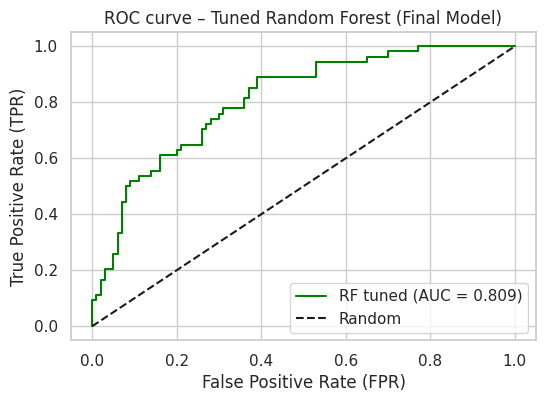

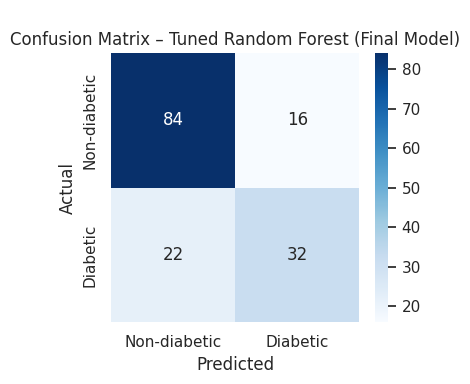

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
import seaborn as sns

# 1) ROC curve for tuned RF (final model)
y_proba_rf_tuned = best_rf_model.predict_proba(X_test_clean)[:, 1]
fpr_rf_tuned, tpr_rf_tuned, _ = roc_curve(y_test_clean, y_proba_rf_tuned)
auc_rf_tuned_test = roc_auc_score(y_test_clean, y_proba_rf_tuned)

plt.figure(figsize=(6, 4))
plt.plot(fpr_rf_tuned, tpr_rf_tuned,
         color="green",
         label=f"RF tuned (AUC = {auc_rf_tuned_test:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC curve – Tuned Random Forest (Final Model)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# 2) Confusion matrix for tuned RF on test set
y_pred_rf_tuned = best_rf_model.predict(X_test_clean)
cm_rf_tuned = confusion_matrix(y_test_clean, y_pred_rf_tuned)

plt.figure(figsize=(4, 4))
sns.heatmap(cm_rf_tuned,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Non-diabetic", "Diabetic"],
            yticklabels=["Non-diabetic", "Diabetic"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("\nConfusion Matrix – Tuned Random Forest (Final Model)")
plt.tight_layout()
plt.show()

**Fig. 12** ROC curve of the final tuned Random Forest classifier on the test set.

**Fig. 13.** Confusion matrix of the final tuned Random Forest classifier on the test set.

###7.2 Ensemble vs single best model(RF)


In [ ]:
ensemble_results = []

def add_ensemble_row(name, f1, auc):
    ensemble_results.append({
        "Model": name,
        "F1 (Test)": f1,
        "ROC-AUC (Test)": auc
    })

# Best tuned RF single model on test set
add_ensemble_row(
    "Random Forest (best single)",
    f1_rf_tuned_test,
    auc_rf_tuned_test
)


# 3-model soft voting
add_ensemble_row("LR + SVM + RF (soft voting)", f1_vs, auc_vs)

# 2-model soft voting
add_ensemble_row("LR + RF (soft voting)", f1_lr_rf, auc_lr_rf)

ensemble_df = pd.DataFrame(ensemble_results)
ensemble_df

,Model,F1 (Test),ROC-AUC (Test)
0,Random Forest (best single),0.627451,0.809259
1,LR + SVM + RF (soft voting),0.525253,0.815000
2,LR + RF (soft voting),0.596154,0.812222


Table 7

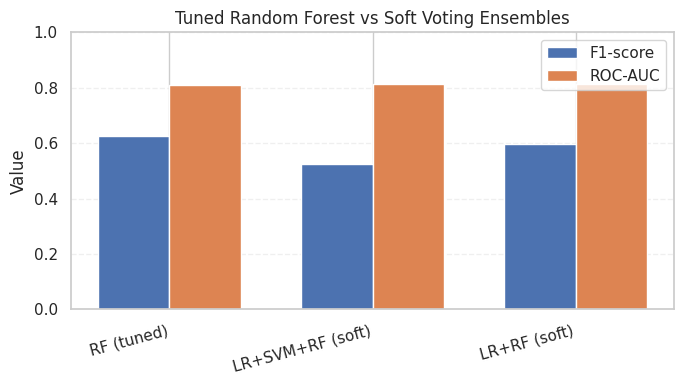

In [ ]:
models = ["RF (tuned)", "LR+SVM+RF (soft)", "LR+RF (soft)"]

f1_values  = [f1_rf_tuned_test, f1_vs,        f1_lr_rf]
auc_values = [auc_rf_tuned_test, auc_vs,      auc_lr_rf]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(7, 4))
plt.bar(x - width/2, f1_values,  width, label="F1-score")
plt.bar(x + width/2, auc_values, width, label="ROC-AUC")

plt.xticks(x, models, rotation=15, ha="right")
plt.ylabel("Value")
plt.title("Tuned Random Forest vs Soft Voting Ensembles")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

**Fig. 14.** Comparison of F1 and ROC-AUC for the tuned Random Forest and soft voting ensembles.

In [ ]:
# Summary table for all models (using previously calculated metrics)

summary_rows = []

def add_summary_row(name, auc, acc, recall, precision, f1):
    summary_rows.append({
        "Classifier": name,
        "AUC": auc,
        "Accuracy": acc,
        "Sensitivity (Recall)": recall,
        "Precision": precision,
        "F1-score": f1
    })

# Metrics are now calculated in O1Dn5CbIL7gP
add_summary_row("Logistic Regression (tuned)", auc_lr_tuned_test, acc_lr_tuned_test,
                recall_lr_tuned_test, prec_lr_tuned_test, f1_lr_tuned_test)

add_summary_row("SVM (tuned)",                auc_svm_tuned_test, acc_svm_tuned_test,
                recall_svm_tuned_test, prec_svm_tuned_test, f1_svm_tuned_test)

add_summary_row("Random Forest (tuned)",      auc_rf_tuned_test, acc_rf_tuned_test,
                recall_rf_tuned_test, prec_rf_tuned_test, f1_rf_tuned_test)

# Ensemble metrics (assumed to be defined by this point)
add_summary_row("LR + SVM + RF (soft)",       auc_vs, acc_vs, recall_vs, prec_vs, f1_vs)

add_summary_row("LR + RF (soft)",             auc_lr_rf, acc_lr_rf,
                recall_lr_rf, prec_lr_rf, f1_lr_rf)

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,Classifier,AUC,Accuracy,Sensitivity (Recall),Precision,F1-score
0,Logistic Regression (tuned),0.809815,0.701299,0.518519,0.583333,0.549020
1,SVM (tuned),0.814630,0.701299,0.481481,0.590909,0.530612
2,Random Forest (tuned),0.809259,0.753247,0.592593,0.666667,0.627451
3,LR + SVM + RF (soft),0.815000,0.694805,0.481481,0.577778,0.525253
4,LR + RF (soft),0.812222,0.727273,0.574074,0.620000,0.596154


**Table 8.** Comparison of performance metrics for all implemented classifiers.

## 7.3 Key observations

- Tuned Random Forest achieved the highest F1-score among single models.
- Logistic Regression remained competitive with slightly lower F1 but similar ROC-AUC.
- SVM performed lower than RF and LR in F1 but still achieved reasonable AUC.
- 10-fold CV increased variance for all models; 5-fold CV gave more stable estimates.
- Simple voting ensembles did not outperform the best tuned Random Forest.